In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [2]:
data = pd.read_csv(
    "combine.csv",
    low_memory=False,
    dtype={"Destination Port": "Int64"}
)

In [3]:
data.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2214469 entries, 0 to 2214468
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             object 
 1    Flow Duration                float64
 2    Total Fwd Packets            float64
 3    Total Backward Packets       float64
 4   Total Length of Fwd Packets   float64
 5    Total Length of Bwd Packets  float64
 6    Fwd Packet Length Max        float64
 7    Fwd Packet Length Min        float64
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         float64
 11   Bwd Packet Length Min        float64
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [5]:
pd.options.display.max_columns = 80
data

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.00000,0.0,0.0,0.0,0.0,4.000000e+06,666666.666700,3.0,0.000000,3.0,3.0,3.0,3.00000,0.00000,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,666666.666700,0.000000,6.0,6.0,6.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.000000,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,33.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.00000,6.0,6.0,6.0,0.0,1.100917e+05,18348.623850,109.0,0.000000,109.0,109.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,9174.311927,9174.311927,6.0,6.0,6.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.000000,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,29.0,256.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.00000,6.0,6.0,6.0,0.0,2.307692e+05,38461.538460,52.0,0.000000,52.0,52.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,19230.769230,19230.769230,6.0,6.0,6.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.000000,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,29.0,256.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.00000,6.0,6.0,6.0,0.0,3.529412e+05,58823.529410,34.0,0.000000,34.0,34.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,29411.764710,29411.764710,6.0,6.0,6.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.000000,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,31.0,329.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.00000,0.0,0.0,0.0,0.0,4.000000e+06,666666.666700,3.0,0.000000,3.0,3.0,3.0,3.00000,0.00000,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,666666.666700,0.000000,6.0,6.0,6.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.000000,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,32.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2214464,53,324.0,2.0,2.0,84.0,362.0,42.0,42.0,42.0,0.00000,181.0,181.0,181.0,0.0,1.376543e+06,12345.679010,108.0,183.597386,320.0,2.0,2.0,2.00000,0.00000,2.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,40.0,40.0,6172.839506,6172.839506,42.0,181.0,97.600000,76.133435,5796.300000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,122.000000,42.0,181.0,40.0,0.0,0.

In [6]:
data.columns = data.columns.str.strip()

In [7]:
dups = data[data.duplicated()]
print(f'Tekrarlanan satır sayısı: {len(dups)}')

Tekrarlanan satır sayısı: 271598


In [8]:
data.drop_duplicates(inplace = True)
data.shape

(1942871, 79)

In [9]:
#sonsuz degerleri kontrol etmek için
numeric_cols = data.select_dtypes(include = np.number).columns
inf_count = np.isinf(data[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Flow Bytes/s      1041
Flow Packets/s    1214
dtype: int64


In [10]:
print(f'İşleme başlamadan önce eksik değer sayısı: {data.isna().sum().sum()}')
data.replace([np.inf, -np.inf], np.nan, inplace = True)
print(f'Sonsuz değerler işlendi, eksik değer sayısı: {data.isna().sum().sum()}')

İşleme başlamadan önce eksik değer sayısı: 255
Sonsuz değerler işlendi, eksik değer sayısı: 2510


In [11]:
missing = data.isna().sum()
print(missing.loc[missing > 0])

Flow Duration                  1
Total Fwd Packets              1
Total Backward Packets         1
Total Length of Fwd Packets    1
Total Length of Bwd Packets    1
                              ..
Idle Mean                      1
Idle Std                       1
Idle Max                       1
Idle Min                       1
Label                          1
Length: 78, dtype: int64


In [12]:
data = data[data.isnull().sum(axis=1) != 1]

In [13]:
missing = data.isna().sum()
print(missing.loc[missing > 0])

Flow Duration                  1
Total Fwd Packets              1
Total Backward Packets         1
Total Length of Fwd Packets    1
Total Length of Bwd Packets    1
                              ..
Idle Mean                      1
Idle Std                       1
Idle Max                       1
Idle Min                       1
Label                          1
Length: 78, dtype: int64


In [14]:
data

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.00000,0.0,0.0,0.0,0.0,4.000000e+06,666666.666700,3.0,0.000000,3.0,3.0,3.0,3.00000,0.00000,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,666666.666700,0.000000,6.0,6.0,6.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.000000,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,33.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.00000,6.0,6.0,6.0,0.0,1.100917e+05,18348.623850,109.0,0.000000,109.0,109.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,9174.311927,9174.311927,6.0,6.0,6.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.000000,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,29.0,256.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.00000,6.0,6.0,6.0,0.0,2.307692e+05,38461.538460,52.0,0.000000,52.0,52.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,19230.769230,19230.769230,6.0,6.0,6.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.000000,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,29.0,256.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.00000,6.0,6.0,6.0,0.0,3.529412e+05,58823.529410,34.0,0.000000,34.0,34.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,29411.764710,29411.764710,6.0,6.0,6.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.000000,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,31.0,329.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.00000,0.0,0.0,0.0,0.0,4.000000e+06,666666.666700,3.0,0.000000,3.0,3.0,3.0,3.00000,0.00000,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,666666.666700,0.000000,6.0,6.0,6.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.000000,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,32.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2214464,53,324.0,2.0,2.0,84.0,362.0,42.0,42.0,42.0,0.00000,181.0,181.0,181.0,0.0,1.376543e+06,12345.679010,108.0,183.597386,320.0,2.0,2.0,2.00000,0.00000,2.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,40.0,40.0,6172.839506,6172.839506,42.0,181.0,97.600000,76.133435,5796.300000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,122.000000,42.0,181.0,40.0,0.0,0.

In [15]:
data['Label'].unique()

array(['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Infiltration',
       'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye',
       'Heartbleed', nan], dtype=object)

In [16]:
attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack Brute Force': 'Web Attack',
    'Web Attack  XSS': 'Web Attack',
    'Web Attack  Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

data=data.copy()
data['Attack Type'] = data['Label'].map(attack_map)

In [17]:
data['Attack Type'].value_counts()

Attack Type
BENIGN          1528283
DoS              193748
DDoS             128016
Port Scan         90819
Bot                1953
Infiltration         36
Heartbleed           11
Name: count, dtype: int64

In [18]:
data.drop('Label', axis = 1, inplace = True)

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Attack Number'] = le.fit_transform(data['Attack Type'])

print(data['Attack Number'].unique())

[0 2 6 1 5 3 4 7]


In [20]:
encoded_values = data['Attack Number'].unique()
for val in sorted(encoded_values):
    print(f"{val}: {le.inverse_transform([val])[0]}")

0: BENIGN
1: Bot
2: DDoS
3: DoS
4: Heartbleed
5: Infiltration
6: Port Scan
7: nan


In [21]:
corr = data.corr(numeric_only = True).round(2)
corr.style.background_gradient(cmap = 'coolwarm', axis = None).format(precision = 2)
     

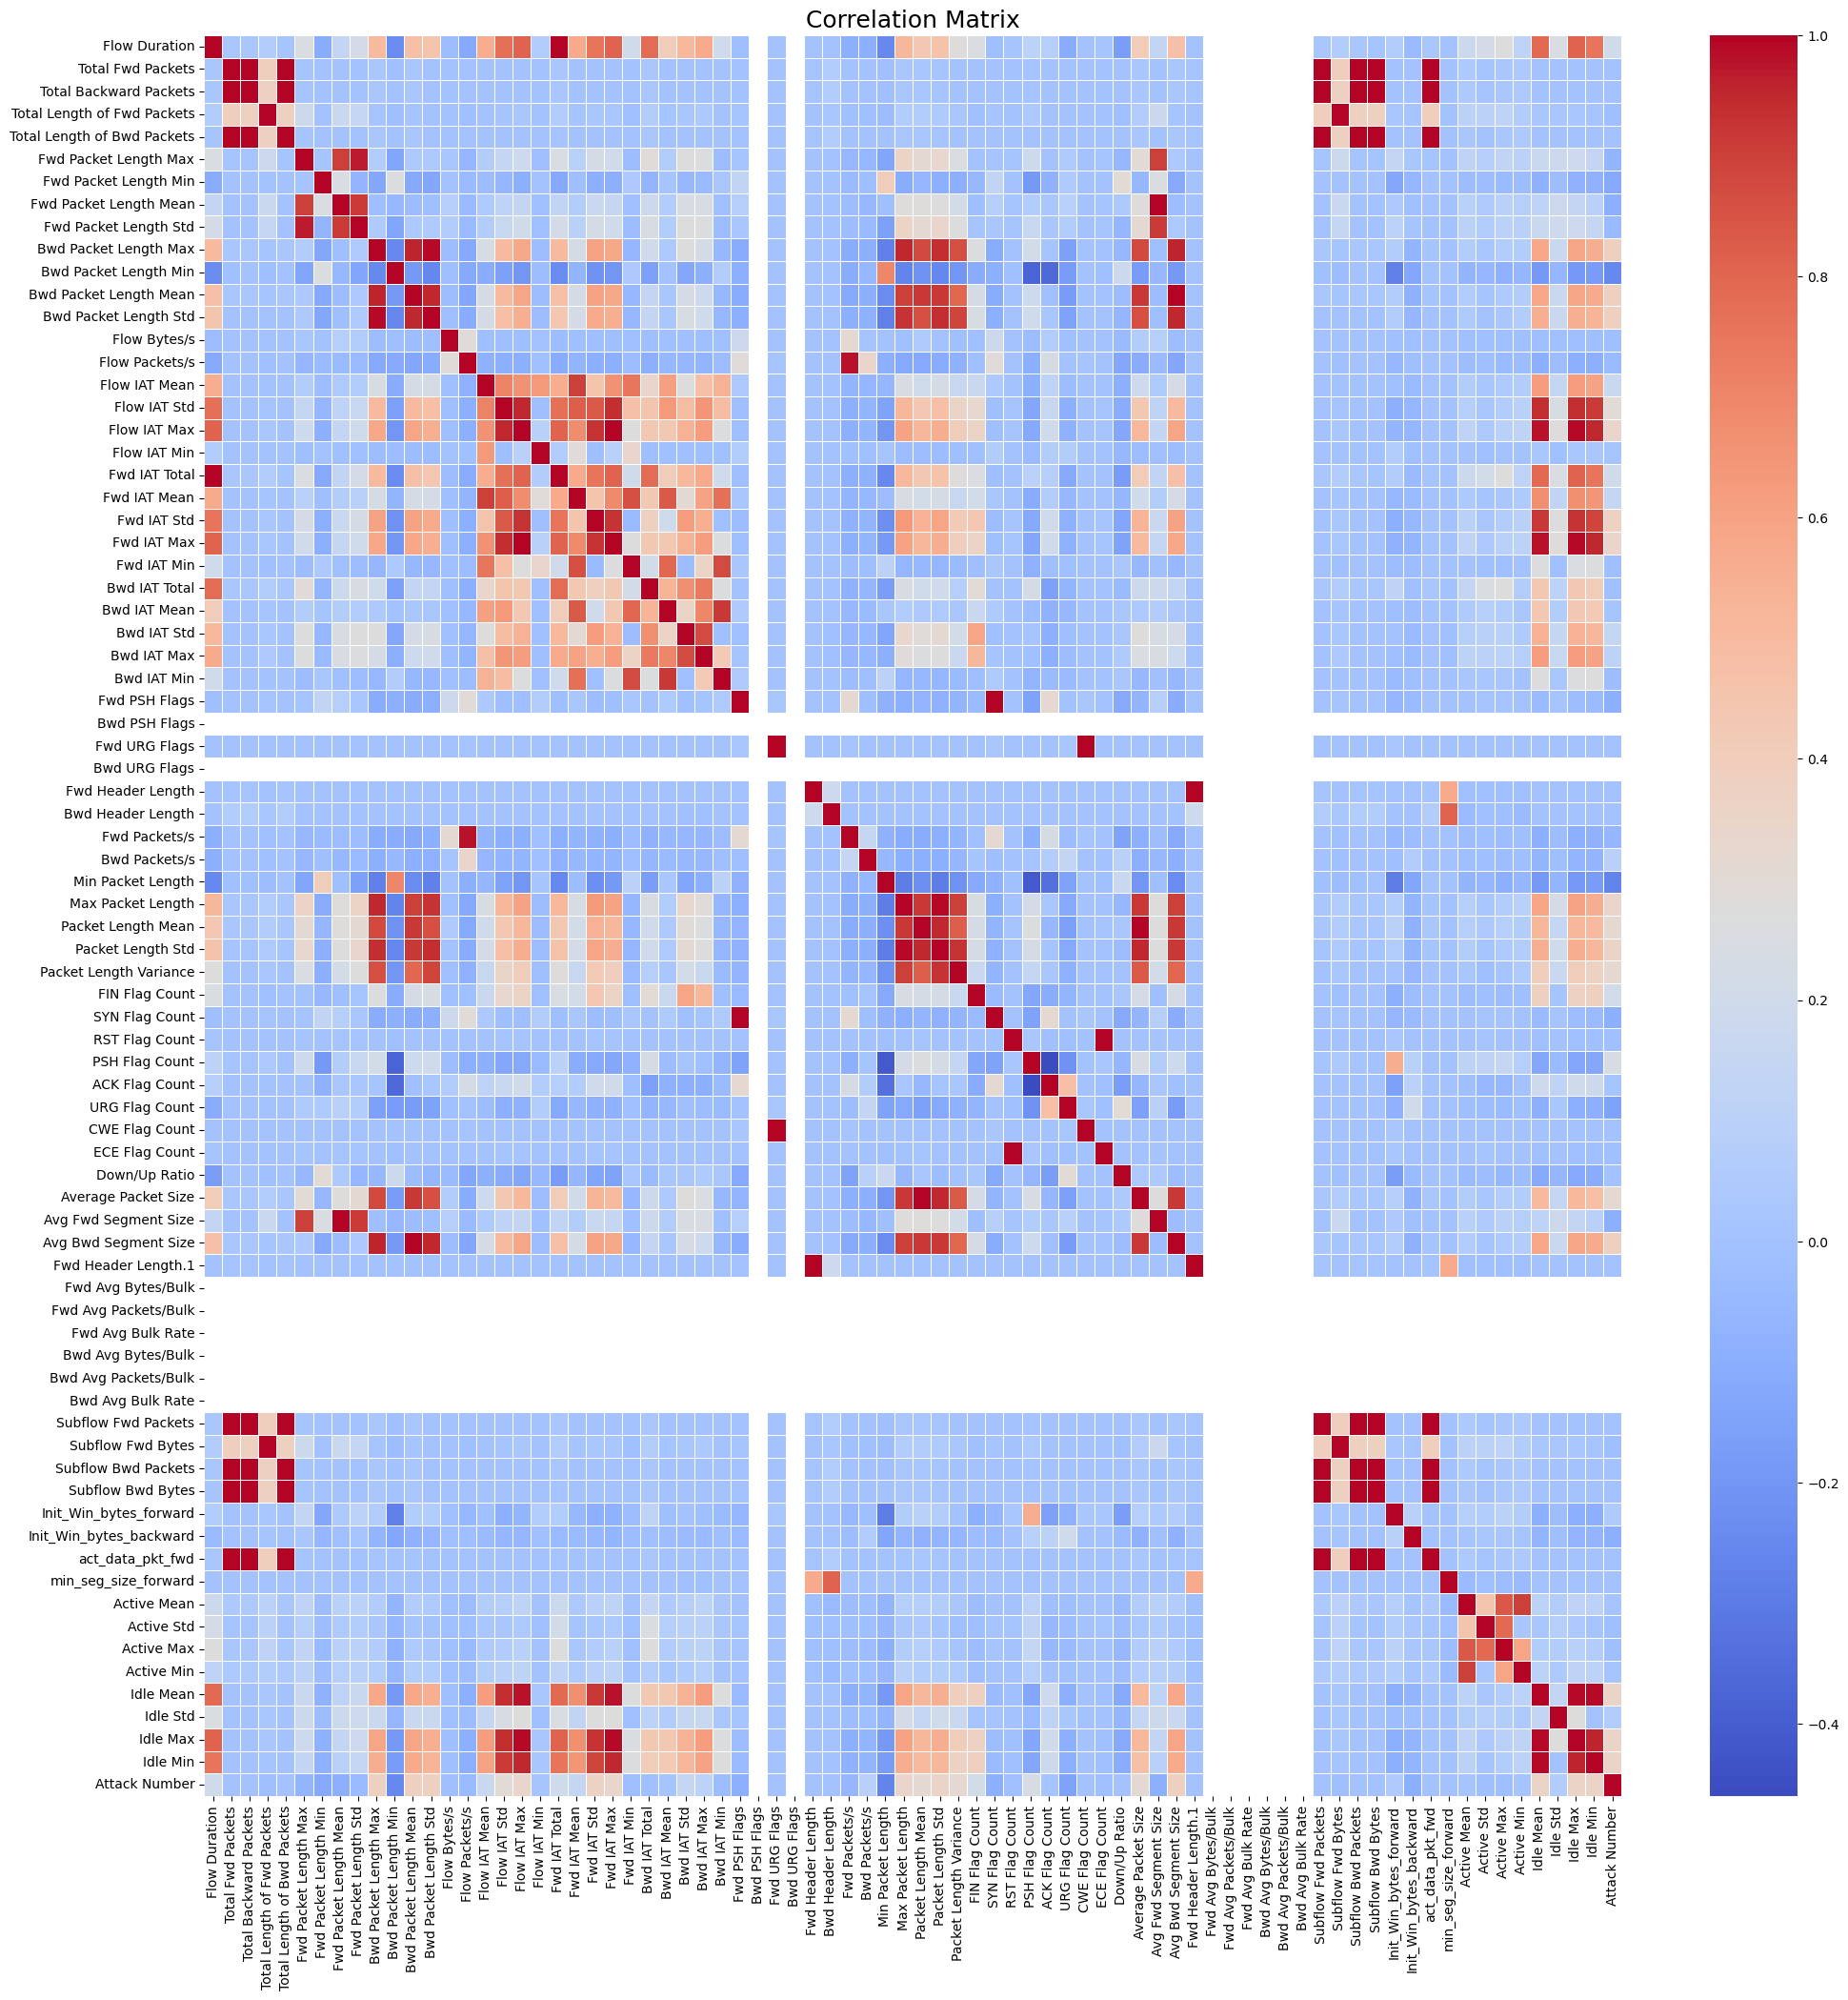

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize = (24, 24))
sns.heatmap(corr, cmap = 'coolwarm', annot = False, linewidth = 0.5)
plt.title('Correlation Matrix', fontsize = 18)
plt.show()

In [23]:
pos_corr_features = corr['Attack Number'][(corr['Attack Number'] > 0) & (corr['Attack Number'] < 1)].index.tolist()

print("Features with positive correlation with 'Attack Number':\n")
for i, feature in enumerate(pos_corr_features, start = 1):
    corr_value = corr.loc[feature, 'Attack Number']
    print('{:<3} {:<24} :{}'.format(f'{i}.', feature, corr_value))

Features with positive correlation with 'Attack Number':

1.  Flow Duration            :0.2
2.  Bwd Packet Length Max    :0.38
3.  Bwd Packet Length Mean   :0.38
4.  Bwd Packet Length Std    :0.38
5.  Flow IAT Mean            :0.17
6.  Flow IAT Std             :0.3
7.  Flow IAT Max             :0.34
8.  Flow IAT Min             :0.01
9.  Fwd IAT Total            :0.2
10. Fwd IAT Mean             :0.15
11. Fwd IAT Std              :0.37
12. Fwd IAT Max              :0.34
13. Bwd IAT Mean             :0.01
14. Bwd IAT Std              :0.15
15. Bwd IAT Max              :0.11
16. Bwd Packets/s            :0.09
17. Max Packet Length        :0.34
18. Packet Length Mean       :0.31
19. Packet Length Std        :0.35
20. Packet Length Variance   :0.32
21. FIN Flag Count           :0.21
22. PSH Flag Count           :0.24
23. ACK Flag Count           :0.01
24. Average Packet Size      :0.31
25. Avg Bwd Segment Size     :0.38
26. Init_Win_bytes_forward   :0.05
27. Active Mean              :0.01


In [24]:
print(f'Dikkate değer önemli özelliklerin sayısı: {len(pos_corr_features)}')

Dikkate değer önemli özelliklerin sayısı: 32


In [25]:
# Sıfır standart sapmaya sahip sütunların kontrolü (heatmap’te boş kareler olarak görünenler)
std = data.std(numeric_only = True)
zero_std_cols = std[std == 0].index.tolist()
zero_std_cols
     

['Bwd PSH Flags',
 'Bwd URG Flags',
 'Fwd Avg Bytes/Bulk',
 'Fwd Avg Packets/Bulk',
 'Fwd Avg Bulk Rate',
 'Bwd Avg Bytes/Bulk',
 'Bwd Avg Packets/Bulk',
 'Bwd Avg Bulk Rate']

In [26]:
# Performansı artırmak ve bellekle ilgili hataları azaltmak için
old_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in data.columns:
    col_type = data[col].dtype
    if col_type != object:
        c_min = data[col].min()
        c_max = data[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            data[col] = data[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            data[col] = data[col].astype(np.int32)

new_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")

Initial memory usage: 1200.65 MB
Final memory usage: 622.56 MB


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1942867 entries, 0 to 2214468
Data columns (total 80 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             object 
 1   Flow Duration                float32
 2   Total Fwd Packets            float32
 3   Total Backward Packets       float32
 4   Total Length of Fwd Packets  float32
 5   Total Length of Bwd Packets  float32
 6   Fwd Packet Length Max        float32
 7   Fwd Packet Length Min        float32
 8   Fwd Packet Length Mean       float32
 9   Fwd Packet Length Std        float32
 10  Bwd Packet Length Max        float32
 11  Bwd Packet Length Min        float32
 12  Bwd Packet Length Mean       float32
 13  Bwd Packet Length Std        float32
 14  Flow Bytes/s                 float32
 15  Flow Packets/s               float32
 16  Flow IAT Mean                float32
 17  Flow IAT Std                 float32
 18  Flow IAT Max                 float32
 19  Flow 

In [28]:

#Tek değerli sütunları veri setinden çıkarma
num_unique = data.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = data[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index(['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
       'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')

In [29]:
# İkili Sınıflandırma için Dengeli Veri Seti Oluşturma
new_data=data.copy()
normal_traffic = new_data.loc[new_data['Attack Type'] == 'BENIGN']
intrusions = new_data.loc[new_data['Attack Type'] != 'BENIGN']

normal_traffic = normal_traffic.sample(n = len(intrusions), replace = False)

ids_data = pd.concat([intrusions, normal_traffic])
ids_data['Attack Type'] = np.where((ids_data['Attack Type'] == 'BENIGN'), 0, 1)
bc_data = ids_data.sample(n = 15000)

print(bc_data['Attack Type'].value_counts())

Attack Type
0    7549
1    7451
Name: count, dtype: int64


In [30]:
# model eğitimi için veriyi özellikler (X) ve hedef (y) olarak ayırmak ve eğitim ile test setlerine bölme
from sklearn.model_selection import train_test_split

X_bc = bc_data.drop('Attack Type', axis = 1)
y_bc = bc_data['Attack Type']

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size = 0.25, random_state = 0)

In [31]:
from sklearn.impute import SimpleImputer

# Sayısal sütunlar için ortalama ile doldurma
imputer = SimpleImputer(strategy='mean')

X_train_bc = pd.DataFrame(imputer.fit_transform(X_train_bc), columns=X_train_bc.columns)
X_test_bc = pd.DataFrame(imputer.transform(X_test_bc), columns=X_test_bc.columns)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr1 = LogisticRegression(max_iter = 10000, C = 0.1, random_state = 0, solver = 'saga')
lr1.fit(X_train_bc, y_train_bc)

cv_lr1 = cross_val_score(lr1, X_train_bc, y_train_bc, cv = 5)
print('Logistic regression Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_lr1)))
print(f'\nMean cross-validation score: {cv_lr1.mean():.2f}')

Logistic regression Model 1

Cross-validation scores: 0.7835555555555556, 0.7724444444444445, 0.8008888888888889, 0.7742222222222223, 0.7937777777777778

Mean cross-validation score: 0.78


In [33]:
print('Logistic Regression Model 1 coefficients:')
print(*lr1.coef_, sep = ', ')
print('\nLogistic Regression Model 1 intercept:', *lr1.intercept_)

Logistic Regression Model 1 coefficients:
[-1.31810821e-07 -2.63232607e-07 -2.45213051e-11 -2.59540164e-11
 -8.95430720e-09  3.96372570e-08 -4.74541459e-09 -3.49959354e-10
 -1.43943269e-09 -1.79290567e-09  1.44509113e-09 -8.76062919e-10
 -1.46938535e-10  1.01292632e-09 -7.48556087e-07  1.04203531e-07
  3.84182194e-07  4.80322322e-07 -2.80678733e-07  1.82046266e-08
  2.74345613e-07 -2.41295098e-07 -1.22662908e-08 -2.57721124e-08
  1.05965733e-08 -1.11114240e-07 -1.28278558e-07  8.65978336e-08
  7.47511208e-08  5.79262747e-08 -4.27632353e-13 -3.72958817e-15
  7.55531309e-09  7.42419549e-09 -6.11808187e-08  1.65716454e-07
 -3.21120315e-10 -1.97961959e-09 -5.99556000e-10 -5.53673304e-10
  6.78244324e-07  4.79753007e-13 -4.27632353e-13 -4.05664417e-15
  2.30608353e-12 -2.66894960e-12 -2.26199937e-12 -3.72958817e-15
 -4.05664417e-15 -5.37404576e-12 -7.45860556e-10 -1.43943269e-09
 -1.46938535e-10  7.55531309e-09 -2.45213051e-11 -8.95430720e-09
 -2.59540164e-11  3.96372570e-08 -1.19186972e-08

In [34]:
lr2 = LogisticRegression(max_iter = 15000, solver = 'sag', C = 100, random_state = 0)
lr2.fit(X_train_bc, y_train_bc)

cv_lr2 = cross_val_score(lr2, X_train_bc, y_train_bc, cv = 3)
print('Logistic regression Model 2')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_lr2)))
print(f'\nMean cross-validation score: {cv_lr2.mean():.2f}')

Logistic regression Model 2

Cross-validation scores: 0.7794666666666666, 0.7928, 0.7893333333333333

Mean cross-validation score: 0.79


In [35]:
print('Logistic Regression Model 2 coefficients:')
print(*lr2.coef_, sep = ', ')
print('\nLogistic Regression Model 2 intercept:', *lr2.intercept_)

Logistic Regression Model 2 coefficients:
[-3.44173040e-07 -2.39082053e-07 -5.93938983e-11 -6.22409320e-11
 -2.30709233e-08  1.12572563e-07 -1.23132566e-08 -9.08381403e-10
 -3.75948069e-09 -4.67170356e-09  2.91772903e-09 -2.29032659e-09
 -6.99012811e-10  2.25920186e-09 -7.90491403e-07  3.45845921e-07
  4.42154196e-07  6.46838773e-07 -4.24438826e-07  6.15054774e-08
  2.52773794e-07 -3.86569553e-07  4.84480518e-08  1.73471357e-08
  1.14357615e-07 -1.39498536e-07 -2.03928988e-07  8.98354213e-08
  1.14465959e-07  9.78983135e-08 -1.06805441e-12 -1.02345813e-14
  6.98803173e-09  6.65438532e-09 -1.14973382e-07  4.61597605e-07
 -8.39745129e-10 -6.06694150e-09 -1.77695434e-09 -1.81201984e-09
  7.08095661e-07  1.24565698e-12 -1.06805441e-12 -1.06458374e-14
  6.38003877e-12 -7.33068924e-12 -5.96273355e-12 -1.02345813e-14
 -1.06458374e-14 -1.39656516e-11 -2.19209417e-09 -3.75948069e-09
 -6.99012811e-10  6.98803173e-09 -5.93938983e-11 -2.30709233e-08
 -6.22409320e-11  1.12572563e-07 -2.51727975e-08

In [36]:
from sklearn.svm import SVC

svm1 = SVC(kernel = 'poly', C = 1, random_state = 0, probability = True)
svm1.fit(X_train_bc, y_train_bc)

cv_svm1 = cross_val_score(svm1, X_train_bc, y_train_bc, cv = 5)
print('Support Vector Machine Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_svm1)))
print(f'\nMean cross-validation score: {cv_svm1.mean():.2f}')

Support Vector Machine Model 1

Cross-validation scores: 0.7017777777777777, 0.6875555555555556, 0.7155555555555555, 0.7062222222222222, 0.7

Mean cross-validation score: 0.70


In [37]:
svm2 = SVC(kernel = 'rbf', C = 1, gamma = 0.1, random_state = 0, probability = True)
svm2.fit(X_train_bc, y_train_bc)

cv_svm2 = cross_val_score(svm2, X_train_bc, y_train_bc, cv = 5)
print('Support Vector Machine Model 2')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_svm2)))
print(f'\nMean cross-validation score: {cv_svm2.mean():.2f}')

Support Vector Machine Model 2

Cross-validation scores: 0.5057777777777778, 0.5053333333333333, 0.5048888888888889, 0.5048888888888889, 0.5062222222222222

Mean cross-validation score: 0.51


In [38]:
print('SVM Model 1 intercept:', *svm1.intercept_)
print('SVM Model 2 intercept:', *svm2.intercept_)

SVM Model 1 intercept: -1.000250630390931
SVM Model 2 intercept: -0.016903788697704657


In [39]:
new_data['Attack Type'].value_counts()

Attack Type
BENIGN          1528283
DoS              193748
DDoS             128016
Port Scan         90819
Bot                1953
Infiltration         36
Heartbleed           11
Name: count, dtype: int64

In [40]:
class_counts = new_data['Attack Type'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = new_data[new_data['Attack Type'].isin(class_names)]

dfs = []
for name in class_names:
  df = selected[selected['Attack Type'] == name]
  if len(df) > 2500:
    df = df.sample(n = 5000, random_state = 0)

  dfs.append(df)

df = pd.concat(dfs, ignore_index = True)
df['Attack Type'].value_counts()

Attack Type
BENIGN       5000
DoS          5000
DDoS         5000
Port Scan    5000
Bot          1953
Name: count, dtype: int64

In [41]:
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
import pandas as pd

# X ve y'yi ayır
X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

# Eksik değerleri medyan ile doldur
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# SMOTE ile azınlık sınıfları artır
smote = SMOTE(sampling_strategy='auto', random_state=0)
X_upsampled, y_upsampled = smote.fit_resample(X, y)

# Tekrar DataFrame oluştur ve karıştır
blnc_data = pd.DataFrame(X_upsampled, columns=X.columns)
blnc_data['Attack Type'] = y_upsampled
blnc_data = blnc_data.sample(frac=1, random_state=0)

# Sınıf dağılımını göster
print(blnc_data['Attack Type'].value_counts())

Attack Type
DDoS         5000
DoS          5000
Bot          5000
BENIGN       5000
Port Scan    5000
Name: count, dtype: int64


In [42]:
features = blnc_data.drop('Attack Type', axis = 1)
labels = blnc_data['Attack Type']

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size = 0.25, random_state = 0)

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf1 = RandomForestClassifier(n_estimators = 10, max_depth = 6, max_features = None, random_state = 0)
rf1.fit(X_train, y_train)

cv_rf1 = cross_val_score(rf1, X_train, y_train, cv = 5)
print('Random Forest Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_rf1)))
print(f'\nMean cross-validation score: {cv_rf1.mean():.2f}')

Random Forest Model 1

Cross-validation scores: 1.0, 1.0, 1.0, 1.0, 1.0

Mean cross-validation score: 1.00


In [44]:
rf2 = RandomForestClassifier(n_estimators = 15, max_depth = 8, max_features = 20, random_state = 0)
rf2.fit(X_train, y_train)

cv_rf2 = cross_val_score(rf2, X_train, y_train, cv = 5)
print('Random Forest Model 2')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_rf2)))
print(f'\nMean cross-validation score: {cv_rf2.mean():.2f}')
     

Random Forest Model 2

Cross-validation scores: 1.0, 1.0, 1.0, 0.9992, 1.0

Mean cross-validation score: 1.00


In [45]:
from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(max_depth = 6)
dt1.fit(X_train, y_train)

cv_dt1 = cross_val_score(dt1, X_train, y_train, cv = 5)
print('Decision Tree Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_dt1)))
print(f'\nMean cross-validation score: {cv_dt1.mean():.2f}')

Decision Tree Model 1

Cross-validation scores: 1.0, 1.0, 1.0, 1.0, 1.0

Mean cross-validation score: 1.00


In [46]:
dt2 = DecisionTreeClassifier(max_depth = 8)
dt2.fit(X_train, y_train)

cv_dt2 = cross_val_score(dt2, X_train, y_train, cv = 5)
print('Decision Tree Model 2')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_dt2)))
print(f'\nMean cross-validation score: {cv_dt2.mean():.2f}')

Decision Tree Model 2

Cross-validation scores: 1.0, 1.0, 1.0, 1.0, 1.0

Mean cross-validation score: 1.00


In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn1 = KNeighborsClassifier(n_neighbors = 16)
knn1.fit(X_train, y_train)

cv_knn1 = cross_val_score(knn1, X_train, y_train, cv = 5)
print('K Nearest Neighbors Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_knn1)))
print(f'\nMean cross-validation score: {cv_knn1.mean():.2f}')

K Nearest Neighbors Model 1

Cross-validation scores: 0.9482666666666667, 0.9493333333333334, 0.9386666666666666, 0.9410666666666667, 0.9397333333333333

Mean cross-validation score: 0.94


In [48]:
knn2 = KNeighborsClassifier(n_neighbors = 8)
knn2.fit(X_train, y_train)

cv_knn2 = cross_val_score(knn2, X_train, y_train, cv = 5)
print('K Nearest Neighbors Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_knn2)))
print(f'\nMean cross-validation score: {cv_knn2.mean():.2f}')

K Nearest Neighbors Model 1

Cross-validation scores: 0.9605333333333334, 0.9618666666666666, 0.9506666666666667, 0.9485333333333333, 0.9536

Mean cross-validation score: 0.96


In [49]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr1),
        ('svm', svm1)
    ],
    voting='soft'
)

voting_clf.fit(X_train_bc, y_train_bc)

y_pred = voting_clf.predict(X_test_bc)

In [50]:
print(y_pred)

[0 0 0 ... 1 1 0]


In [51]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_bc, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8173333333333334


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bc)
X_test_scaled = scaler.transform(X_test_bc)

In [53]:
lr1.fit(X_train_scaled, y_train_bc)
svm1.fit(X_train_scaled, y_train_bc)

,C,1
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [54]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr1),
        ('svm', svm1)
    ],
    voting='soft'
)

voting_clf.fit(X_train_scaled, y_train_bc)

y_pred = voting_clf.predict(X_test_scaled)

In [55]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_bc, y_pred)
print("New Accuracy:", accuracy)

New Accuracy: 0.9976


In [56]:
from sklearn.metrics import accuracy_score

lr_pred = lr1.predict(X_test_scaled)
svm_pred = svm1.predict(X_test_scaled)
voting_pred = voting_clf.predict(X_test_scaled)

results = {
    "Logistic Regression": accuracy_score(y_test_bc, lr_pred),
    "SVM": accuracy_score(y_test_bc, svm_pred),
    "Voting Classifier": accuracy_score(y_test_bc, voting_pred)
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.9979
SVM: 0.9760
Voting Classifier: 0.9976


In [57]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

lr1 = LogisticRegression(max_iter=10000, C=0.1, random_state=0, solver='saga')

knn1 = KNeighborsClassifier(n_neighbors=16)

voting_lr_knn = VotingClassifier(
    estimators=[
        ('lr', lr1),
        ('knn', knn1)
    ],
    voting='soft'
)

In [58]:
voting_lr_knn.fit(X_train_scaled, y_train_bc)

,estimators,"[('lr', ...), ('knn', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True


In [59]:
y_pred = voting_lr_knn.predict(X_test_scaled)

In [60]:
from sklearn.metrics import accuracy_score

print("LR + KNN Voting Accuracy:", accuracy_score(y_test_bc, y_pred))

LR + KNN Voting Accuracy: 0.9968


In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test_bc, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1879
           1       1.00      1.00      1.00      1871

    accuracy                           1.00      3750
   macro avg       1.00      1.00      1.00      3750
weighted avg       1.00      1.00      1.00      3750



In [62]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test_bc, y_pred))

[[1876    3]
 [   9 1862]]


In [63]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

svm1 = SVC(kernel='poly', C=1, probability=True, random_state=0)
knn1 = KNeighborsClassifier(n_neighbors=16)

voting_svm_knn = VotingClassifier(
    estimators=[
        ('svm', svm1),
        ('knn', knn1)
    ],
    voting='soft'
)

In [64]:
voting_svm_knn.fit(X_train_scaled, y_train_bc)

,estimators,"[('svm', ...), ('knn', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0


In [65]:
y_pred = voting_svm_knn.predict(X_test_scaled)

In [66]:
from sklearn.metrics import accuracy_score

print("SVM + KNN Voting Accuracy:", accuracy_score(y_test_bc, y_pred))

SVM + KNN Voting Accuracy: 0.9938666666666667


In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_bc, y_pred)
print(cm)

[[1873    6]
 [  17 1854]]


In [68]:
import pandas as pd

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0 (Normal)", "Actual 1 (Attack)"],
    columns=["Predicted 0", "Predicted 1"]
)

print(cm_df)

                   Predicted 0  Predicted 1
Actual 0 (Normal)         1873            6
Actual 1 (Attack)           17         1854
